## media de mensualidades en las que se aplazan los pedidos

<ipython-input-36-4033376055>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_media, x='Tipo de Pago', y='Media de Cuotas', palette='pastel')


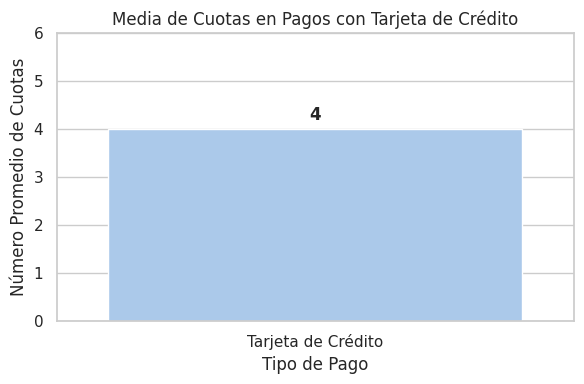

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la media de cuotas para pagos con tarjeta
media_cuotas = df_credit['payment_installments'].mean()
media_cuotas_redondeada = round(media_cuotas)

# 2. Crear DataFrame para visualización
df_media = pd.DataFrame({
    'Tipo de Pago': ['Tarjeta de Crédito'],
    'Media de Cuotas': [media_cuotas_redondeada]
})

# 3. Visualización
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df_media, x='Tipo de Pago', y='Media de Cuotas', palette='pastel')

# Etiqueta encima de la barra
plt.text(0, media_cuotas_redondeada + 0.1, f'{media_cuotas_redondeada}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Título y etiquetas
plt.title('Media de Cuotas en Pagos con Tarjeta de Crédito')
plt.ylabel('Número Promedio de Cuotas')
plt.ylim(0, media_cuotas_redondeada + 2)
plt.tight_layout()
plt.show()


## Precio medio de pedidos pagados a cuotas

<ipython-input-37-272360809>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_precio, x='Tipo de Pago', y='Precio Medio', palette='muted')


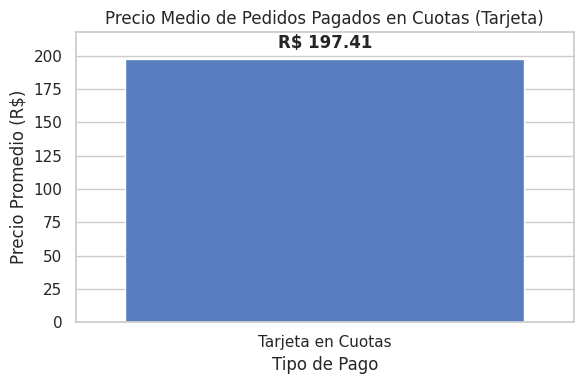

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar pagos con tarjeta y en cuotas (más de 1)
df_cuotas_credit = df[(df['payment_type'] == 'credit_card') & (df['payment_installments'] > 1)]

# 2. Agrupar por pedido para obtener el monto total por pedido
pagos_por_pedido = df_cuotas_credit.groupby('order_id')['payment_value'].sum().reset_index()

# 3. Calcular precio medio
precio_medio = pagos_por_pedido['payment_value'].mean()
precio_medio_redondeado = round(precio_medio, 2)

# 4. Crear DataFrame para visualizar
df_precio = pd.DataFrame({
    'Tipo de Pago': ['Tarjeta en Cuotas'],
    'Precio Medio': [precio_medio_redondeado]
})

# 5. Visualización
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df_precio, x='Tipo de Pago', y='Precio Medio', palette='muted')

# Etiqueta encima de la barra
plt.text(0, precio_medio_redondeado + 5, f'R$ {precio_medio_redondeado}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Título y etiquetas
plt.title('Precio Medio de Pedidos Pagados en Cuotas (Tarjeta)')
plt.ylabel('Precio Promedio (R$)')
plt.ylim(0, precio_medio_redondeado + 20)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# 1) Leer el CSV con los datos de pagos
df = pd.read_csv('olist_order_payments_dataset.csv')

# 2) Crear una nueva columna 'forma_pago':
#    - Si payment_installments == 1 → "al_contado"
#    - Si payment_installments > 1 → "cuotas"
def categorizar_pago(row):
    if row['payment_installments'] == 1:
        return 'al_contado'
    else:
        return 'cuotas'

df['forma_pago'] = df.apply(categorizar_pago, axis=1)

# 3) Filtrar solo los pagos con tarjeta de crédito (credit_card) y con boleto (boleto)
df_credit = df[df['payment_type'] == 'credit_card'].copy()
df_boleto = df[df['payment_type'] == 'boleto'].copy()

# 4) Mostrar conteo de al_contado vs. cuotas para cada tipo de pago
conteo_credit = df_credit['forma_pago'].value_counts().rename_axis('forma_pago').reset_index(name='conteo')
conteo_boleto = df_boleto['forma_pago'].value_counts().rename_axis('forma_pago').reset_index(name='conteo')

print("=== Credit Card ===")
print(conteo_credit.to_string(index=False))
print("\n=== Boleto ===")
print(conteo_boleto.to_string(index=False))

# (Opcional) Si quieres ver los primeros registros con la nueva columna:
print("\nPrimeras filas de 'credit_card' con la columna 'forma_pago':")
print(df_credit.head().to_string(index=False))

print("\nPrimeras filas de 'boleto' con la columna 'forma_pago':")
print(df_boleto.head().to_string(index=False))


=== Credit Card ===
forma_pago  conteo
    cuotas   51340
al_contado   25455

=== Boleto ===
forma_pago  conteo
al_contado   19784

Primeras filas de 'credit_card' con la columna 'forma_pago':
                        order_id  payment_sequential payment_type  payment_installments  payment_value forma_pago
b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card                     8          99.33     cuotas
a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card                     1          24.39 al_contado
25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card                     1          65.71 al_contado
ba78997921bbcdc1373bb41e913ab953                   1  credit_card                     8         107.78     cuotas
42fdf880ba16b47b59251dd489d4441a                   1  credit_card                     2         128.45     cuotas

Primeras filas de 'boleto' con la columna 'forma_pago':
                        order_id  payment_sequential payment_type 

## Pedido más caro y más barato a plazos

In [ ]:
import pandas as pd

# 1. Cargar los datos
df = pd.read_csv('olist_order_payments_dataset.csv')

# 2. Filtrar pagos en cuotas
df_cuotas = df[df['payment_installments'] > 1]

# 3. Agrupar por pedido y sumar el valor total
pedido_total = df_cuotas.groupby('order_id')['payment_value'].sum().reset_index()

# 4. Obtener el pedido más barato y el más caro
pedido_min = pedido_total.loc[pedido_total['payment_value'].idxmin()]
pedido_max = pedido_total.loc[pedido_total['payment_value'].idxmax()]

# 5. Mostrar los resultados
print("=== Pedido con el valor más BAJO pagado en cuotas ===")
print(f"Order ID: {pedido_min['order_id']}")
print(f"Valor total: R$ {pedido_min['payment_value']:.2f}")

print("\n=== Pedido con el valor más ALTO pagado en cuotas ===")
print(f"Order ID: {pedido_max['order_id']}")
print(f"Valor total: R$ {pedido_max['payment_value']:.2f}")


=== Pedido con el valor más BAJO pagado en cuotas ===
Order ID: 74db91e33b4e1fd865356c89a61abf1f
Valor total: R$ 20.03

=== Pedido con el valor más ALTO pagado en cuotas ===
Order ID: 0812eb902a67711a1cb742b3cdaa65ae
Valor total: R$ 6929.31


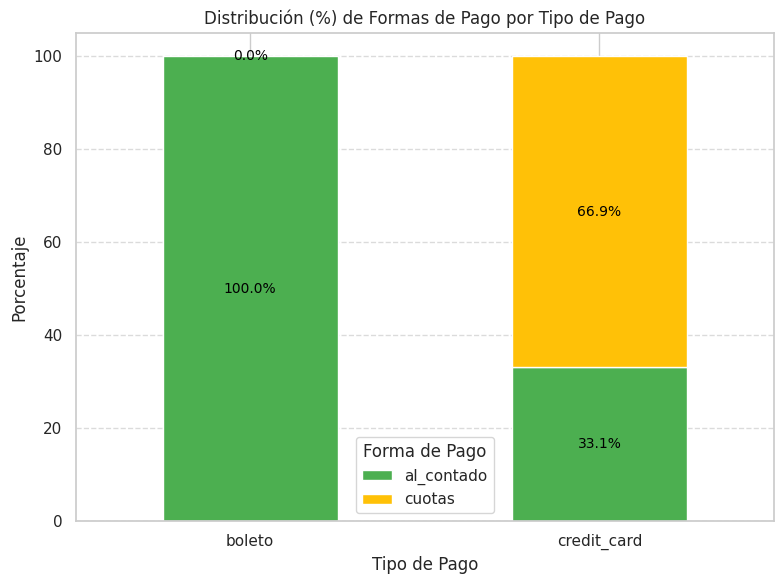

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV
df = pd.read_csv('olist_order_payments_dataset.csv')

# Clasificar los pagos
df['forma_pago'] = df['payment_installments'].apply(lambda x: 'al_contado' if x == 1 else 'cuotas')

# Filtrar por tipos relevantes
df_filtrado = df[df['payment_type'].isin(['credit_card', 'boleto'])]

# Contar formas de pago por tipo de pago
conteo = df_filtrado.groupby(['payment_type', 'forma_pago']).size().unstack(fill_value=0)

# Calcular porcentajes por fila
porcentajes = conteo.div(conteo.sum(axis=1), axis=0) * 100

# Crear visualización
ax = porcentajes.plot(
    kind='bar',
    stacked=True,
    color=['#4CAF50', '#FFC107'],  # Verde y amarillo
    figsize=(8, 6)
)

# Añadir etiquetas de porcentaje en las barras
for i, (idx, row) in enumerate(porcentajes.iterrows()):
    bottom = 0
    for j, val in enumerate(row):
        plt.text(i, bottom + val / 2, f"{val:.1f}%", ha='center', va='center', fontsize=10, color='black')
        bottom += val

# Personalizar gráfico
plt.title('Distribución (%) de Formas de Pago por Tipo de Pago')
plt.xlabel('Tipo de Pago')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Forma de Pago')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [ ]:
import pandas as pd
from datetime import datetime
import holidays

# --- Cargar datasets ---
df_pagos = pd.read_csv('olist_order_payments_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')

# --- Clasificar como al contado o cuotas ---
df_pagos['forma_pago'] = df_pagos['payment_installments'].apply(lambda x: 'al_contado' if x == 1 else 'cuotas')

# --- Unir pagos con órdenes para obtener la fecha del pedido ---
df_pagos_con_fecha = df_pagos.merge(df_orders[['order_id', 'order_approved_at']], on='order_id', how='left')

# Convertir la fecha a datetime
df_pagos_con_fecha['order_approved_at'] = pd.to_datetime(df_pagos_con_fecha['order_approved_at'], errors='coerce')

# --- Marcar si la fecha es feriado ---
br_holidays = holidays.Brazil()

def es_feriado(fecha):
    if pd.isna(fecha):
        return False
    return fecha.date() in br_holidays

df_pagos_con_fecha['es_feriado'] = df_pagos_con_fecha['order_approved_at'].apply(es_feriado)

# --- Unir con los artículos para obtener productos por pedido ---
df_final = df_pagos_con_fecha.merge(df_items[['order_id', 'product_id']], on='order_id', how='left')

# --- Seleccionar columnas clave ---
df_resultado = df_final[['order_id', 'product_id', 'forma_pago', 'order_approved_at', 'es_feriado']]

# Ordenar por fecha
df_resultado = df_resultado.sort_values(by='order_approved_at')

# Mostrar primeras filas
print(df_resultado.head())


                                order_id                        product_id  \
19421   1ff217aa612f6cd7c4255c9bfe931c8b  33430c5c1027d812b5c62f778e5ee7f7   
100791  65d1e226dfaeb8cdc42f665422522d14  9c7bdf67b06b419aefb93cfdfc96c55d   
53194   cd3b8574c82b42fc8129f6d502690c3e  e2a1d45a73dc7f5a7f9236b043431b89   
28240   ed8c7b1b3eb256c70ce0c74231e1da88  29bedbfbe73ea473396306b4f0c010ec   
48265   1aecadf4362edaca7fa033e882076c8d                               NaN   

        forma_pago   order_approved_at  es_feriado  
19421       cuotas 2016-10-04 09:43:32       False  
100791  al_contado 2016-10-04 10:18:57       False  
53194       cuotas 2016-10-04 10:19:23       False  
28240   al_contado 2016-10-04 10:25:46       False  
48265       cuotas 2016-10-04 10:26:40       False  
